In [1]:
.libPaths(c('/project/yangili1/cfbuenabadn/R/x86_64-pc-linux-gnu-library/4.1',
            '/software/R-4.1.0-el8-x86_64/lib64/R/library')) 

# library(glue)
library(tidyverse)
library(dplyr)
library(ggplot2)
library(bedr)
library(readr)

library(ACAT)
library(data.table)
library(ComplexHeatmap)

Warning message:
"'timedatectl' indicates the non-existent timezone name 'n/a'"
unable to deduce timezone name from 'America/Chicago'

-- Attaching packages ------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 1.3.1 --

v ggplot2 3.5.2     v purrr   1.0.4
v tibble  3.2.1     v dplyr   1.1.4
v tidyr   1.3.1     v stringr 1.5.1
v readr   1.4.0     v forcats 0.5.1

-- Conflicts --------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()



######################
#### bedr v1.0.7 ####
######################

checking binary availability...
  * Checking path for bedtools... PASS
    /scratch/midway3/cnajar/anaconda3/envs/leafcutter2/bin/bedtools
  * Checking path for bedops... FAIL
  * Checki

In [2]:
psi <- read.table('../code/analysis_files/GTEx.psi.tsv.gz', sep='\t', header=TRUE)
counts <- read.table('../code/analysis_files/GTEx.cluster_counts.tsv.gz', sep='\t', header=TRUE)
tissues <- colnames(counts)[7:1231]

In [3]:
library(dplyr)

result <- counts %>%
  # 1) Median across tissues per cluster
  rowwise() %>%
  mutate(
    cluster_median = median(c_across(all_of(tissues)), na.rm = TRUE)
  ) %>%
  ungroup() %>%
  
  # keep one row per cluster
  distinct(gene_id, gene_name, cluster, cluster_median) %>%
  
  # 2) Max median per gene
  group_by(gene_id) %>%
  mutate(
    gene_max = max(cluster_median)
  ) %>%
  ungroup() %>%
  
  # 3) Fraction (PSI-like)
  mutate(
    cluster_psi = cluster_median / gene_max
  ) %>%
  
  # final output
  select(gene_id, gene_name, cluster, cluster_median, gene_max, cluster_psi)


In [15]:
result %>% filter(cluster_psi >= 0.5)

gene_id,gene_name,cluster,cluster_median,gene_max,cluster_psi
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000107566.13,ERLIN1,chr10:clu_24473_-,8.0,8,1.0000000
ENSG00000213341.10,CHUK,chr10:clu_24474_-,21.0,23,0.9130435
ENSG00000213341.10,CHUK,chr10:clu_24474_-,23.0,23,1.0000000
ENSG00000095485.16,CWF19L1,chr10:clu_24475_-,79.0,102,0.7745098
ENSG00000095485.16,CWF19L1,chr10:clu_24476_-,62.5,102,0.6127451
ENSG00000095485.16,CWF19L1,chr10:clu_24476_-,84.0,102,0.8235294
ENSG00000095485.16,CWF19L1,chr10:clu_24476_-,102.0,102,1.0000000
ENSG00000095485.16,CWF19L1,chr10:clu_24477_-,90.0,102,0.8823529
ENSG00000095485.16,CWF19L1,chr10:clu_24478_-,79.0,102,0.7745098


In [12]:
comparisons <- sub("\\.rds$", "", list.files('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'))

comparisons <- comparisons[!grepl("Bladder", comparisons)]

get_sig_clusters <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
    sig_genes <- rds$dge %>% filter(padj <= 1e-2, abs(log2FoldChange) >= 2) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-2, itype=='UP', ctype=='PR,UP',
                                 (gene_id %in% sig_genes)) %>% pull(cluster) %>% unique()
    
    sig_clusters2 <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-2, itype=='UP', ctype=='PR,UP') %>% pull(cluster) %>% unique()
    return(list(ds_dge=sig_clusters,ds=sig_clusters2))
}

get_sig_clusters2 <- function(comparison) {
    path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
    rds = readRDS(glue::glue(path_dir, '{comparison}.rds'))
#     sig_genes <- rds$dge %>% filter(padj <= 5e-2, abs(log2FoldChange) >= 0.1) %>% pull(gene_id) %>% unique()
    sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-2, itype=='UP', ctype=='PR,UP') %>% pull(cluster) %>% unique()
    return(sig_clusters)
}




cluster_list <- c()
cluster_all <- c()


cluster_list2 <- c()
cluster_all2 <- c()
pb = txtProgressBar(min = 0, max = length(comparisons), initial = 0) 
stepi <- 0
for (comparison in comparisons) {
    sig_clusters_list <- get_sig_clusters(comparison)
    cluster_list <- union(cluster_list, sig_clusters_list$ds_dge)
    cluster_all <- c(cluster_all, sig_clusters_list$ds_dge)
    
    
    
    cluster_list2 <- union(cluster_list2, sig_clusters_list$ds)
#     cluster_all2 <- c(cluster_all2, sig_clusters2)
    
    
    setTxtProgressBar(pb,stepi)
    stepi <- stepi + 1
}
close(pb)

In [5]:
# path_dir <- '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/'
# rds = readRDS(glue::glue(path_dir, 'Testis_v_Liver.rds'))
# sig_genes <- rds$dge %>% filter(padj <= 1e-10, abs(log2FoldChange) >= 2) %>% pull(gene_id) %>% unique()
# sig_clusters <- rds$ds %>% filter(abs(deltapsi) >= 0.2, p.adjust <= 1e-10, itype=='UP', ctype=='PR,UP',
#                              (gene_id %in% sig_genes)) %>% pull(cluster) %>% unique()

In [16]:
result %>% filter(cluster_psi >= 0.5)

gene_id,gene_name,cluster,cluster_median,gene_max,cluster_psi
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000107566.13,ERLIN1,chr10:clu_24473_-,8.0,8,1.0000000
ENSG00000213341.10,CHUK,chr10:clu_24474_-,21.0,23,0.9130435
ENSG00000213341.10,CHUK,chr10:clu_24474_-,23.0,23,1.0000000
ENSG00000095485.16,CWF19L1,chr10:clu_24475_-,79.0,102,0.7745098
ENSG00000095485.16,CWF19L1,chr10:clu_24476_-,62.5,102,0.6127451
ENSG00000095485.16,CWF19L1,chr10:clu_24476_-,84.0,102,0.8235294
ENSG00000095485.16,CWF19L1,chr10:clu_24476_-,102.0,102,1.0000000
ENSG00000095485.16,CWF19L1,chr10:clu_24477_-,90.0,102,0.8823529
ENSG00000095485.16,CWF19L1,chr10:clu_24478_-,79.0,102,0.7745098


In [197]:
cluster_list_ <- cluster_list[cluster_list %in% (result %>% filter(cluster_psi >= 0.5) %>% pull(cluster))]

In [198]:
length(unique(cluster_list))

[1] 1751

In [199]:
ds_df <- cluster_list %>% table() %>% as.data.frame()
colnames(ds_df) <- c('cluster', 'freq')

In [200]:
# psi <- read.table('../code/analysis_files/GTEx.psi.tsv.gz', sep='\t', header=TRUE)
# counts <- read.table('../code/analysis_files/GTEx.cluster_counts.tsv.gz', sep='\t', header=TRUE)
psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), ctype == 'PR,UP') %>% pull(cluster) %>% unique() %>% length()

[1] 1751

In [201]:
psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), ctype == 'PR,UP')

intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr10:100498207:100498704:clu_24487_-,chr10:clu_24487_-,PR,"PR,UP",SEC31B,ENSG00000075826.16,0.3007262092,0.326783615,3.313157e-01,3.241735e-01,⋯,2.982270e-01,3.604205e-01,0.342642246,0.338632429,3.303941e-01,3.573748e-01,0.310703050,0.327816097,0.3049878269,0.340678815
chr10:100498207:100499159:clu_24487_-,chr10:clu_24487_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.2903566590,0.247571430,2.408751e-01,2.417582e-01,⋯,2.742707e-01,1.805201e-01,0.211172139,0.185946751,2.087605e-01,1.129350e-01,0.301559877,0.245051415,0.2907946237,0.174686816
chr10:100498804:100499159:clu_24487_-,chr10:clu_24487_-,PR,"PR,UP",SEC31B,ENSG00000075826.16,0.4089171319,0.425644955,4.278091e-01,4.340683e-01,⋯,4.275023e-01,4.590594e-01,0.446185615,0.475420819,4.608455e-01,5.296902e-01,0.387737073,0.427132488,0.4042175494,0.484634369
chr10:100508048:100508460:clu_24491_-,chr10:clu_24491_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.0009771331,0.120638642,4.881934e-02,3.295422e-04,⋯,1.027095e-03,2.806301e-06,0.001713852,0.001777032,2.953472e-03,2.395735e-03,0.002379315,0.002206053,0.0011308290,0.002844602
chr10:100508048:100509006:clu_24491_-,chr10:clu_24491_-,PR,"PR,UP",SEC31B,ENSG00000075826.16,0.3948844079,0.347725148,3.868563e-01,4.005332e-01,⋯,3.926840e-01,3.991076e-01,0.410549139,0.400016527,4.225504e-01,4.270916e-01,0.415745063,0.407701199,0.3652493484,0.423928171
chr10:100508051:100509006:clu_24491_-,chr10:clu_24491_-,PR,"PR,UP",SEC31B,ENSG00000075826.16,0.6041384590,0.531636211,5.643244e-01,5.991372e-01,⋯,6.062889e-01,6.008896e-01,0.587737008,0.598206441,5.744961e-01,5.705127e-01,0.581875623,0.590092748,0.6336198226,0.573227228
chr10:100509102:100509315:clu_24492_-,chr10:clu_24492_-,PR,"PR,UP",SEC31B,ENSG00000075826.16,0.4502429802,0.438895923,4.936624e-01,4.517977e-01,⋯,4.912266e-01,4.837478e-01,0.452254895,0.468445502,4.622126e-01,4.644206e-01,0.489413220,0.478089075,0.4737781269,0.498557238
chr10:100509102:100516095:clu_24492_-,chr10:clu_24492_-,UP,"PR,UP",SEC31B,ENSG00000075826.16,0.1158654221,0.114389323,5.690358e-02,1.435922e-01,⋯,5.569200e-02,6.986361e-02,0.131731177,0.102549995,1.060006e-01,1.089996e-01,0.043362505,0.058539417,0.0506273475,0.055715642
chr10:100509511:100516095:clu_24492_-,chr10:clu_24492_-,PR,"PR,UP",SEC31B,ENSG00000075826.16,0.4338915977,0.446714754,4.494341e-01,4.046101e-01,⋯,4.530814e-01,4.463886e-01,0.416013929,0.429004502,4.317868e-01,4.265797e-01,0.467224275,0.463371508,0.4755945256,0.445727121


In [202]:
# up_psi

In [203]:
up_psi <- psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), itype == 'UP', ctype == 'PR,UP')
up_psi <- up_psi[rowSums(is.na(up_psi)) <= 0,]

tissues <- (up_psi %>% colnames())[7:56]
X <- up_psi[rowSums(is.na(up_psi)) <= 0, tissues]
rownames(X) <- up_psi[rowSums(is.na(up_psi)) <= 0,]$intron

In [204]:
tissues <- (psi %>% colnames())[7:56]

up_psi <- psi %>% filter(cluster %in% (ds_df %>% pull(cluster)), itype == 'UP', ctype == 'PR,UP') %>%
  group_by(gene_id) %>%
  summarise(
    across(all_of(tissues), ~ mean(.x, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  tibble::column_to_rownames("gene_id")

up_psi <- up_psi[rowSums(is.na(up_psi)) <= 0,]


X <- up_psi[rowSums(is.na(up_psi)) <= 0, tissues]
# rownames(X) <- up_psi[rowSums(is.na(up_psi)) <= 0,]$intron

In [205]:
X

,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,Adipose.Visceral_Omentum,AdrenalGland,Artery.Coronary,Bladder,Brain.Amygdala,Brain.Anteriorcingulatecortex_BA24,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000001036.13,0.0173024680,0.0658785164,0.0319997044,0.0224903685,0.0097296418,1.040641e-02,0.0197078867,3.328856e-02,0.033900388,0.0546316831,⋯,0.0050199513,0.0029550061,0.0242234573,0.012110548,0.005630136,0.0254389165,0.0057429050,0.0084364954,0.0037521736,0.0072958176
ENSG00000001460.17,0.0145827542,0.1261075945,0.1165017771,0.0353806201,0.0239394056,3.177546e-02,0.0266489418,1.664474e-02,0.119169456,0.1297039285,⋯,0.0191491689,0.0549152654,0.0341044459,0.020923205,0.042786414,0.1720966895,0.0168606785,0.0142405973,0.0273689788,0.0202500929
ENSG00000001497.16,0.1680023716,0.5818862555,0.6194662784,0.3571544747,0.1333549738,1.768234e-01,0.1555113575,2.479361e-01,0.433171650,0.4922292612,⋯,0.1390032003,0.0166114485,0.3371041940,0.167139859,0.092510753,0.3493221365,0.2179903647,0.0634902634,0.0712400860,0.0259786421
ENSG00000004139.13,0.0770402695,0.0194320580,0.0245025998,0.0373236834,0.0875169376,2.830092e-02,0.0658687458,5.273463e-02,0.026554405,0.0171747058,⋯,0.0728205825,0.0706343609,0.0507404232,0.098519554,0.149148013,0.0340192990,0.0608283907,0.1156227032,0.1212732893,0.1325930591
ENSG00000004777.18,0.9600266736,0.4225110806,0.3735519689,0.9311576246,0.9536505665,9.403539e-01,0.9474217266,9.462608e-01,0.334350967,0.2421761785,⋯,0.9646220476,0.8773944272,0.9595078149,0.949410946,0.950177099,0.9838443847,0.9655058374,0.9588567824,0.9628860551,0.9415440435
ENSG00000004864.13,0.3126476896,0.1348685299,0.1626374215,0.2572032254,0.1385457397,2.566017e-02,0.2484709508,2.125840e-01,0.097741947,0.1117278631,⋯,0.1522354529,0.1455260605,0.2905431918,0.107947080,0.029063285,0.6207226555,0.2583219058,0.0675548496,0.0755443360,0.3905108263
ENSG00000006025.11,0.2291330879,0.1748793013,0.1512475819,0.2715642716,0.2663177377,1.443246e-01,0.2342387605,2.629866e-01,0.187065479,0.1431794346,⋯,0.2897730427,0.1724460803,0.2330400789,0.173904557,0.234022821,0.3527227574,0.3265550259,0.3520843925,0.3925709279,0.3415339635
ENSG00000006634.7,0.1557646626,0.0712283849,0.0592745304,0.1212824490,0.1549233519,9.171959e-02,0.1320558689,1.602442e-01,0.059210424,0.0766889942,⋯,0.1680781021,0.1014340931,0.1414782514,0.134448103,0.076470779,0.1400437249,0.1425017445,0.1955130655,0.1750543250,0.1768674485
ENSG00000008130.15,0.0149522960,0.0914711061,0.0907911030,0.0336404508,0.0254427495,9.288946e-03,0.0202311602,2.900265e-02,0.072633883,0.0868072111,⋯,0.0151622663,0.0331775917,0.0330428167,0.020210390,0.004605522,0.1265057335,0.0168626240,0.0107011219,0.0066922822,0.0050621657


In [206]:
impute_and_filter <- function(mat) {
  mat %>%
    as.data.frame() %>%
    mutate(row_missing = rowSums(is.na(.))) %>%
    filter(row_missing <= 5) %>%
    select(-row_missing) %>%
    mutate(across(everything(), ~ifelse(is.na(.), mean(., na.rm = TRUE), .)))
}


In [207]:
X %>% dim()

[1] 569  50

In [208]:
gtex_colors <- list(
  "Adipose.Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose.Visceral_Omentum" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "AdrenalGland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery.Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery.Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery.Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery.Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain.Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Anteriorcingulatecortex_BA24" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Caudate_basalganglia" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.CerebellarHemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.FrontalCortex_BA9" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Nucleusaccumbens_basalganglia" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Putamen_basalganglia" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Spinalcord_cervicalc.1" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain.Substantianigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast.MammaryTissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells.EBV.transformedlymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells.Culturedfibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix.Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix.Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon.Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon.Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus.GastroesophagealJunction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus.Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "FallopianTube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart.AtrialAppendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart.LeftVentricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney.Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney.Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "MinorSalivaryGland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle.Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve.Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin.NotSunExposed_Suprapubic" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin.SunExposed_Lowerleg" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "SmallIntestine.TerminalIleum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "WholeBlood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [209]:
library(ComplexHeatmap)
# library(glue)
library(dplyr)

legendBreaks <- seq(-4, 4, 2)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc <- circlize::colorRamp2(
  breaks = legendBreaks, 
  colors = colors
  )


column_colors <- sapply(colnames(X), function(tissue) {
  paste0("#", gtex_colors[[tissue]]$tissue_color_hex)
})

# Create the heatmap
set.seed(0)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>%
  Heatmap(
    column_title = glue::glue("Unproductive splicing across GTEx tissues, N = {nrow(X)}"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, 
    column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    column_names_gp = gpar(col = column_colors)
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



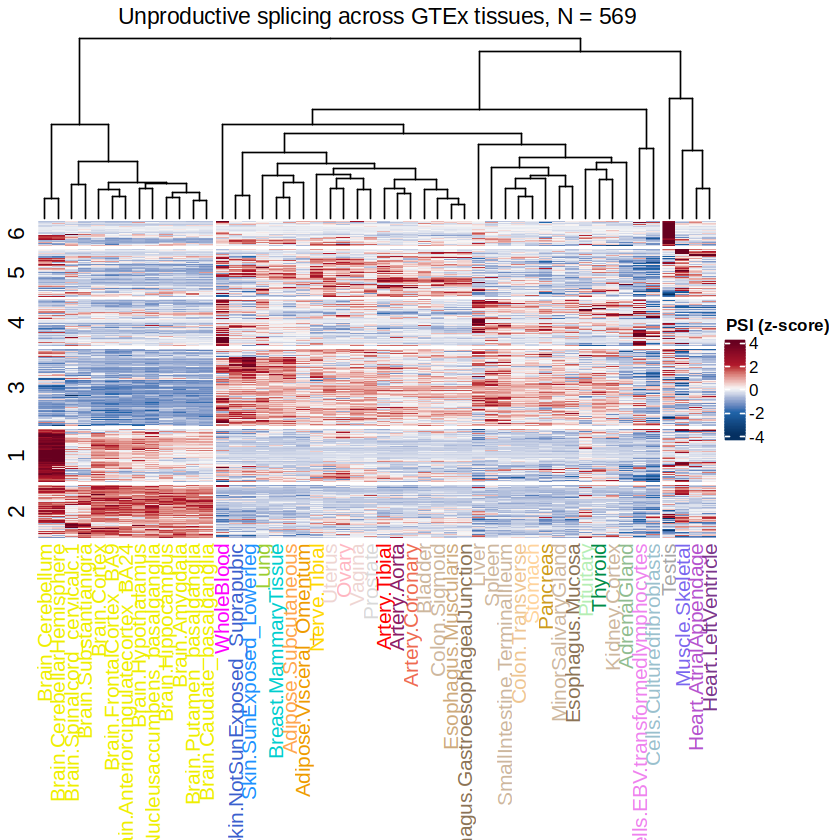

In [210]:
ht

In [211]:
gtex_colors <- list(
  "Adipose - Subcutaneous" = list(
    "tissue_abbrv" = "ADPSBQ", 
    "tissue_color_hex" = "FFA54F", 
    "tissue_color_rgb" = "255,165,79"
  ), 
  "Adipose - Visceral (omentum)" = list(
    "tissue_abbrv" = "ADPVSC", 
    "tissue_color_hex" = "EE9A00", 
    "tissue_color_rgb" = "238,154,0"
  ), 
  "Adrenal gland" = list(
    "tissue_abbrv" = "ADRNLG", 
    "tissue_color_hex" = "8FBC8F", 
    "tissue_color_rgb" = "143,188,143"
  ), 
  "Artery - Aorta" = list(
    "tissue_abbrv" = "ARTAORT", 
    "tissue_color_hex" = "8B1C62", 
    "tissue_color_rgb" = "139,28,98"
  ), 
  "Artery - Coronary" = list(
    "tissue_abbrv" = "ARTCRN", 
    "tissue_color_hex" = "EE6A50", 
    "tissue_color_rgb" = "238,106,80"
  ), 
  "Artery - Femoral" = list(
    "tissue_abbrv" = "ARTFMR", 
    "tissue_color_hex" = "FF4500", 
    "tissue_color_rgb" = "255,69,0"
  ), 
  "Artery - Tibial" = list(
    "tissue_abbrv" = "ARTTBL", 
    "tissue_color_hex" = "FF0000", 
    "tissue_color_rgb" = "255,0,0"
  ), 
  "Bladder" = list(
    "tissue_abbrv" = "BLDDER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Brain - Amygdala" = list(
    "tissue_abbrv" = "BRNAMY", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Anterior cingulate cortex (BA24)" = list(
    "tissue_abbrv" = "BRNACC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Caudate (basal ganglia)" = list(
    "tissue_abbrv" = "BRNCDT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cerebellar hemisphere" = list(
    "tissue_abbrv" = "BRNCHB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cerebellum" = list(
    "tissue_abbrv" = "BRNCHA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Cortex" = list(
    "tissue_abbrv" = "BRNCTXA", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Frontal cortex (BA9)" = list(
    "tissue_abbrv" = "BRNCTXB", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Hippocampus" = list(
    "tissue_abbrv" = "BRNHPP", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Hypothalamus" = list(
    "tissue_abbrv" = "BRNHPT", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Nucleus accumbens (basal ganglia)" = list(
    "tissue_abbrv" = "BRNNCC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Putamen (basal ganglia)" = list(
    "tissue_abbrv" = "BRNPTM", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Spinalcord (cervical c-1)" = list(
    "tissue_abbrv" = "BRNSPC", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Brain - Substantia nigra" = list(
    "tissue_abbrv" = "BRNSNG", 
    "tissue_color_hex" = "EEEE00", 
    "tissue_color_rgb" = "238,238,0"
  ), 
  "Breast - Mammary tissue" = list(
    "tissue_abbrv" = "BREAST", 
    "tissue_color_hex" = "00CDCD", 
    "tissue_color_rgb" = "0,205,205"
  ), 
  "Cells - EBV-transformed lymphocytes" = list(
    "tissue_abbrv" = "LCL", 
    "tissue_color_hex" = "EE82EE", 
    "tissue_color_rgb" = "238,130,238"
  ), 
  "Cells - Cultured fibroblasts" = list(
    "tissue_abbrv" = "FIBRBLS", 
    "tissue_color_hex" = "9AC0CD", 
    "tissue_color_rgb" = "154,192,205"
  ), 
  "Cervix - Ectocervix" = list(
    "tissue_abbrv" = "CVXECT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Cervix - Endocervix" = list(
    "tissue_abbrv" = "CVSEND", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Colon - Sigmoid" = list(
    "tissue_abbrv" = "CLNSGM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Colon - Transverse" = list(
    "tissue_abbrv" = "CLNTRN", 
    "tissue_color_hex" = "EEC591", 
    "tissue_color_rgb" = "238,197,145"
  ), 
  "Esophagus - Gastroesophageal junction" = list(
    "tissue_abbrv" = "ESPGEJ", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus - Mucosa" = list(
    "tissue_abbrv" = "ESPMCS", 
    "tissue_color_hex" = "8B7355", 
    "tissue_color_rgb" = "139,115,85"
  ), 
  "Esophagus - Muscularis" = list(
    "tissue_abbrv" = "ESPMSL", 
    "tissue_color_hex" = "CDAA7D", 
    "tissue_color_rgb" = "205,170,125"
  ), 
  "Fallopian tube" = list(
    "tissue_abbrv" = "FLLPNT", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Heart - Atrial appendage" = list(
    "tissue_abbrv" = "HRTAA", 
    "tissue_color_hex" = "B452CD", 
    "tissue_color_rgb" = "180,82,205"
  ), 
  "Heart - Left ventricle" = list(
    "tissue_abbrv" = "HRTLV", 
    "tissue_color_hex" = "7A378B", 
    "tissue_color_rgb" = "122,55,139"
  ), 
  "Kidney - Cortex" = list(
    "tissue_abbrv" = "KDNCTX", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Kidney - Medulla" = list(
    "tissue_abbrv" = "KDNMDL", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Liver" = list(
    "tissue_abbrv" = "LIVER", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Lung" = list(
    "tissue_abbrv" = "LUNG", 
    "tissue_color_hex" = "9ACD32", 
    "tissue_color_rgb" = "154,205,50"
  ), 
  "Minor salivary gland" = list(
    "tissue_abbrv" = "SLVRYG", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Muscle - Skeletal" = list(
    "tissue_abbrv" = "MSCLSK", 
    "tissue_color_hex" = "7A67EE", 
    "tissue_color_rgb" = "122,103,238"
  ), 
  "Nerve - Tibial" = list(
    "tissue_abbrv" = "NERVET", 
    "tissue_color_hex" = "FFD700", 
    "tissue_color_rgb" = "255,215,0"
  ), 
  "Ovary" = list(
    "tissue_abbrv" = "OVARY", 
    "tissue_color_hex" = "FFB6C1", 
    "tissue_color_rgb" = "255,182,193"
  ), 
  "Pancreas" = list(
    "tissue_abbrv" = "PNCREAS", 
    "tissue_color_hex" = "CD9B1D", 
    "tissue_color_rgb" = "205,155,29"
  ), 
  "Pituitary" = list(
    "tissue_abbrv" = "PTTARY", 
    "tissue_color_hex" = "B4EEB4", 
    "tissue_color_rgb" = "180,238,180"
  ), 
  "Prostate" = list(
    "tissue_abbrv" = "PRSTTE", 
    "tissue_color_hex" = "D9D9D9", 
    "tissue_color_rgb" = "217,217,217"
  ), 
  "Skin - Not sun exposed (suprapubic)" = list(
    "tissue_abbrv" = "SKINNS", 
    "tissue_color_hex" = "3A5FCD", 
    "tissue_color_rgb" = "58,95,205"
  ), 
  "Skin - Sun exposed (lower leg)" = list(
    "tissue_abbrv" = "SKINS", 
    "tissue_color_hex" = "1E90FF", 
    "tissue_color_rgb" = "30,144,255"
  ), 
  "Small intestine - Terminal ileum" = list(
    "tissue_abbrv" = "SNTTRM", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Spleen" = list(
    "tissue_abbrv" = "SPLEEN", 
    "tissue_color_hex" = "CDB79E", 
    "tissue_color_rgb" = "205,183,158"
  ), 
  "Stomach" = list(
    "tissue_abbrv" = "STMACH", 
    "tissue_color_hex" = "FFD39B", 
    "tissue_color_rgb" = "255,211,155"
  ), 
  "Testis" = list(
    "tissue_abbrv" = "TESTIS", 
    "tissue_color_hex" = "A6A6A6", 
    "tissue_color_rgb" = "166,166,166"
  ), 
  "Thyroid" = list(
    "tissue_abbrv" = "THYROID", 
    "tissue_color_hex" = "008B45", 
    "tissue_color_rgb" = "0,139,69"
  ), 
  "Uterus" = list(
    "tissue_abbrv" = "UTERUS", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Vagina" = list(
    "tissue_abbrv" = "VAGINA", 
    "tissue_color_hex" = "EED5D2", 
    "tissue_color_rgb" = "238,213,210"
  ), 
  "Whole blood" = list(
    "tissue_abbrv" = "WHLBLD", 
    "tissue_color_hex" = "FF00FF", 
    "tissue_color_rgb" = "255,0,255"
  )
)

In [212]:
colnames(X) <- c(
    'Artery - Aorta', 'Brain - Cortex', 'Brain - Nucleus accumbens (basal ganglia)', 'Esophagus - Muscularis', 
    'Adipose - Visceral (omentum)', 'Adrenal gland', 'Artery - Coronary', 'Bladder', 'Brain - Amygdala', 
    'Brain - Anterior cingulate cortex (BA24)', 'Brain - Caudate (basal ganglia)', 'Brain - Cerebellar hemisphere', 
    'Brain - Cerebellum', 'Brain - Hypothalamus', 'Brain - Putamen (basal ganglia)', 'Brain - Spinalcord (cervical c-1)', 
    'Brain - Substantia nigra', 'Cells - Cultured fibroblasts', 'Esophagus - Gastroesophageal junction', 
    'Esophagus - Mucosa', 'Heart - Atrial appendage', 
    'Heart - Left ventricle', 'Kidney - Cortex', 'Lung', 'Minor salivary gland', 'Ovary', 'Pancreas', 'Pituitary', 
    'Prostate', 'Small intestine - Terminal ileum', 'Spleen', 'Stomach', 'Testis', 'Thyroid', 'Uterus', 'Vagina', 
    'Adipose - Subcutaneous', 'Artery - Tibial', 'Brain - Frontal cortex (BA9)', 'Brain - Hippocampus', 
    'Breast - Mammary tissue', 'Cells - EBV-transformed lymphocytes', 'Colon - Sigmoid', 'Colon - Transverse', 
    'Liver', 'Muscle - Skeletal', 'Nerve - Tibial', 'Skin - Not sun exposed (suprapubic)', 
    'Skin - Sun exposed (lower leg)', 'Whole blood'
)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



$`1`
 [1] 13 12 16 17  2 39 10 14  3 40  9 15 11

$`2`
 [1] 46 45 35 26 36 29 38  1  7  8 43  4 19  5 28 34 23 30 44 32 27 25 20  6 21
[26] 22 42 18

$`3`
[1] 33 50 48 49 24 47 41 37 31

$`1`
  [1] 471 465 328 145 202 120 477  35 272 320 292 528  82  11 155 304 219  55
 [19]  60  80 350  38 194  29 283 372  68 289   1 256 161 460 331 259 133 401
 [37] 561 535  75  92  47 415  76  74 467 225 558 375  84 398 105 232 553 273
 [55] 482 203  49 552 560 216 569 297 434  50   3  90 347 436 457 281 189 429
 [73] 403 142 176   9 185 502 108 124 127 478 334 156  46 268 512 406 537 380
 [91] 109 181   2 303 427 277 253 122 472 346 368 150 199 314 209 424 129  15
[109] 113 321 162 397  62 547  94 352  34 459 296 290  10 207 458 341 322 421
[127] 260 228 335 462 128 473 432  43 513 523 545 452 317 266 278 566  73 248
[145]  59 267 163 208  52 215 140 456 409  86 324  69 301 384 550 481 378 143
[163] 541  63 498 533 114 359 174 521 244  78 504 544

$`6`
 [1] 511 464 179 371 342 418  44 246 548 271  24 455 166 316 104  89 360 284 491
[20] 210 171  61 298 529 559 169  48 149 250  41 408 501 364 229 442 172 107  98
[39] 146 522 218 192 213

$`5`
 [1] 475 147 539  40 295 173 390 157  66  13 527 254 546 497 463 515  95 280 240
[20] 158 530 125 437 369 392 230 175 356 483 493 407   6  30 286 100 358 243 308
[39] 269 376 282 261 200 102  88 160  21 224 563  45 454 327  16  83 159 387 441
[58] 344 311 106 148 239 141 425 388 212 101 431 377 374 191 353 187 333 177 404
[77] 300 430  14 119 542 391 492 444 235  20 198 223 389 499 423 222

$`4`
 [1] 412 336 265 287 139  32 554 167  70 438 518 503 182  22  54 383 373 274 365
[20] 193 233 136 170 420 484 330  31  12 258 249 237  64 263 131  81 326 468 567
[39] 396 206 294  71 474 355 323  99 227 540 362 190 488  91 379 231 211 562 564
[58] 257 245 339 221

$`3`
 [1] 196 485 135 123 195 419 247 461 367 118 400  36 411 433 312 428 519 313 393
[20]  53  72  19 506 395 557 447 251  87 241 357  57 201  27 279 508 164 137 204
[39] 130 466  67  23 443 183  33 132 126 394 319  18 354 184 345 117 426 310 410
[58] 405  39 524 479 338  77 399 414  79 417  26

$`2`
  [1] 264 510 325 538 453 144 116 236 536 270 514 487 496  93 556  97 551 242
 [19]  58 565 238 495  51  28 568 543 470 332 178 486 293 480 416  37 307 370
 [37]  42 413 445 288 154 214 450 329 103 276 217 549 500  25 435 220 351 291
 [55] 152 151 361 234   4 363 451 318 309 525  56 111 262 165 337 340 402 505
 [73] 115  85 534 306  96 422 134 494 507 489 386 381   5 186   8 520 555 315
 [91] 526 226 448 110 112 469 197 440 153 531 188 285 516 439 349  17 302 490
[109] 252 343 348 532 255 138 168  65 476 305   7 449 385 382 275 446 121 299
[127] 205 366 180 509 517

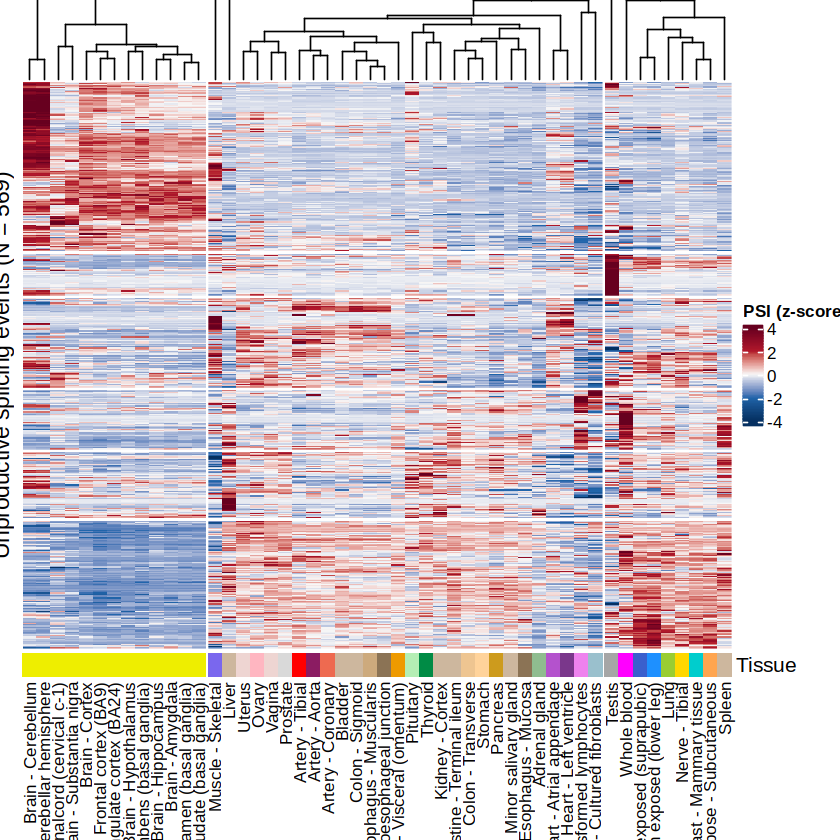

In [213]:
# Define column colors
column_colors <- setNames(
  sapply(colnames(X), function(tissue) paste0("#", gtex_colors[[tissue]]$tissue_color_hex)),
  colnames(X)
)

# Create a heatmap annotation
column_ha <- HeatmapAnnotation(
  Tissue = colnames(X),
  col = list(Tissue = column_colors),
  show_legend = FALSE  # Hide legend if unnecessary
)

# Create the heatmap
set.seed(2)
ht <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    row_km = 6, row_gap = unit(0.5, "mm"), 
    column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    show_row_names = FALSE, clustering_method_rows = "complete", show_row_dend = FALSE,
    clustering_method_columns = "complete", column_dend_height = unit(1.5, "in"), show_column_dend = TRUE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

# ht

ht = draw(ht); column_order(ht); row_order(ht)
# pdf("heatmap_output.pdf", 
# pdf("../code/plots/fig2_heatmap_aver.pdf",  width = 12, height = 15)  # Set dimensions as needed
# draw(ht, raster_quality = 2)  # Lower value = higher quality
# dev.off()
    
# pdf("../code/plots/fig2_heatmap.pdf",  width = 12, height = 15)  # Set dimensions as needed
# draw(ht, raster_quality = 2)  # Lower value = higher quality
# dev.off()

In [214]:
colnames(up_psi) <- c(
    'Artery - Aorta', 'Brain - Cortex', 'Brain - Nucleus accumbens (basal ganglia)', 'Esophagus - Muscularis', 
    'Adipose - Visceral (omentum)', 'Adrenal gland', 'Artery - Coronary', 'Bladder', 'Brain - Amygdala', 
    'Brain - Anterior cingulate cortex (BA24)', 'Brain - Caudate (basal ganglia)', 'Brain - Cerebellar hemisphere', 
    'Brain - Cerebellum', 'Brain - Hypothalamus', 'Brain - Putamen (basal ganglia)', 'Brain - Spinalcord (cervical c-1)', 
    'Brain - Substantia nigra', 'Cells - Cultured fibroblasts', 'Esophagus - Gastroesophageal junction', 
    'Esophagus - Mucosa', 'Heart - Atrial appendage', 
    'Heart - Left ventricle', 'Kidney - Cortex', 'Lung', 'Minor salivary gland', 'Ovary', 'Pancreas', 'Pituitary', 
    'Prostate', 'Small intestine - Terminal ileum', 'Spleen', 'Stomach', 'Testis', 'Thyroid', 'Uterus', 'Vagina', 
    'Adipose - Subcutaneous', 'Artery - Tibial', 'Brain - Frontal cortex (BA9)', 'Brain - Hippocampus', 
    'Breast - Mammary tissue', 'Cells - EBV-transformed lymphocytes', 'Colon - Sigmoid', 'Colon - Transverse', 
    'Liver', 'Muscle - Skeletal', 'Nerve - Tibial', 'Skin - Not sun exposed (suprapubic)', 
    'Skin - Sun exposed (lower leg)', 'Whole blood'
)

In [215]:
median_expression <- read.table('/project2/mstephens/cfbuenabadn/gtex-stm/code/gtex_tables/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz',
                                sep='\t', header=TRUE, skip=2, check.names = FALSE)


In [216]:
tissues <- (up_psi %>% colnames())
rownames(up_psi) <- str_remove(rownames(up_psi), "\\..*$")
median_expression$gene_id <- str_remove(median_expression$Name, "\\..*$")


In [217]:
colnames(median_expression) <- colnames(median_expression) %>% toupper()
colnames(up_psi) <- colnames(up_psi) %>% toupper()
row_order <- row_order(ht)
col_order <- column_order(ht)
# idx <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
# out <- median_expression[idx[!is.na(idx)], ]

In [218]:
col_order['1'][[1]]

[1] 13 12 16 17  2 39 10 14  3 40  9 15 11

In [219]:
up_X <- up_psi
colnames(up_X) <- colnames(up_X) %>% toupper()

cols_orders <- c(colnames(X)[col_order['1'][[1]]], colnames(X)[col_order['2'][[1]]], colnames(X)[col_order['3'][[1]]]) %>% toupper()
idx1 <- match(rownames(up_psi[row_order['1'][[1]],]), median_expression$GENE_ID)
idx2 <- match(rownames(up_psi[row_order['2'][[1]],]), median_expression$GENE_ID)
idx3 <- match(rownames(up_psi[row_order['3'][[1]],]), median_expression$GENE_ID)
idx4 <- match(rownames(up_psi[row_order['4'][[1]],]), median_expression$GENE_ID)
idx5 <- match(rownames(up_psi[row_order['5'][[1]],]), median_expression$GENE_ID)
idx6 <- match(rownames(up_psi[row_order['6'][[1]],]), median_expression$GENE_ID)

rows_orders <- c(idx1, idx2, idx3, idx4, idx5, idx6)

intron_idx1 <- rownames(up_psi[row_order['1'][[1]],])
intron_idx2 <- rownames(up_psi[row_order['2'][[1]],])
intron_idx3 <- rownames(up_psi[row_order['3'][[1]],])
intron_idx4 <- rownames(up_psi[row_order['4'][[1]],])
intron_idx5 <- rownames(up_psi[row_order['5'][[1]],])
intron_idx6 <- rownames(up_psi[row_order['6'][[1]],])

intron_idx <- c(intron_idx1, intron_idx2, intron_idx3, intron_idx4, intron_idx5, intron_idx6)

median_expression['BRAIN - SPINALCORD (CERVICAL C-1)'] <- median_expression['BRAIN - SPINAL CORD (CERVICAL C-1)']

exp_X <- median_expression[rows_orders, cols_orders]
rownames(exp_X) <- median_expression[rows_orders, 'GENE_ID']

In [220]:
cols_orders

[1] "BRAIN - CEREBELLUM"                       
 [2] "BRAIN - CEREBELLAR HEMISPHERE"            
 [3] "BRAIN - SPINALCORD (CERVICAL C-1)"        
 [4] "BRAIN - SUBSTANTIA NIGRA"                 
 [5] "BRAIN - CORTEX"                           
 [6] "BRAIN - FRONTAL CORTEX (BA9)"             
 [7] "BRAIN - ANTERIOR CINGULATE CORTEX (BA24)" 
 [8] "BRAIN - HYPOTHALAMUS"                     
 [9] "BRAIN - NUCLEUS ACCUMBENS (BASAL GANGLIA)"
[10] "BRAIN - HIPPOCAMPUS"                      
[11] "BRAIN - AMYGDALA"                         
[12] "BRAIN - PUTAMEN (BASAL GANGLIA)"          
[13] "BRAIN - CAUDATE (BASAL GANGLIA)"          
[14] "MUSCLE - SKELETAL"                        
[15] "LIVER"                                    
[16] "UTERUS"                                   
[17] "OVARY"                                    
[18] "VAGINA"                                   
[19] "PROSTATE"                                 
[20] "ARTERY - TIBIAL"                          
[21] "ARTERY - AORTA"                           
[22] "ARTERY - CORONARY"                        
[23] "BLADDER"                                  
[24] "COLON - SIGMOID"                          
[25] "ESOPHAGUS - MUSCULARIS"                   
[26] "ESOPHAGUS - GASTROESOPHAGEAL JUNCTION"    
[27] "ADIPOSE - VISCERAL (OMENTUM)"             
[28] "PITUITARY"                                
[29] "THYROID"                                  
[30] "KIDNEY - CORTEX"                          
[31] "SMALL INTESTINE - TERMINAL ILEUM"         
[32] "COLON - TRANSVERSE"                       
[33] "STOMACH"                                  
[34] "PANCREAS"                                 
[35] "MINOR SALIVARY GLAND"                     
[36] "ESOPHAGUS - MUCOSA"                       
[37] "ADRENAL GLAND"                            
[38] "HEART - ATRIAL APPENDAGE"                 
[39] "HEART - LEFT VENTRICLE"                   
[40] "CELLS - EBV-TRANSFORMED LYMPHOCYTES"      
[41] "CELLS - CULTURED FIBROBLASTS"             
[42] "TESTIS"                                   
[43] "WHOLE BLOOD"                              
[44] "SKIN - NOT SUN EXPOSED (SUPRAPUBIC)"      
[45] "SKIN - SUN EXPOSED (LOWER LEG)"           
[46] "LUNG"                                     
[47] "NERVE - TIBIAL"                           
[48] "BREAST - MAMMARY TISSUE"                  
[49] "ADIPOSE - SUBCUTANEOUS"                   
[50] "SPLEEN"

In [221]:
up_X

,ARTERY - AORTA,BRAIN - CORTEX,BRAIN - NUCLEUS ACCUMBENS (BASAL GANGLIA),ESOPHAGUS - MUSCULARIS,ADIPOSE - VISCERAL (OMENTUM),ADRENAL GLAND,ARTERY - CORONARY,BLADDER,BRAIN - AMYGDALA,BRAIN - ANTERIOR CINGULATE CORTEX (BA24),⋯,BREAST - MAMMARY TISSUE,CELLS - EBV-TRANSFORMED LYMPHOCYTES,COLON - SIGMOID,COLON - TRANSVERSE,LIVER,MUSCLE - SKELETAL,NERVE - TIBIAL,SKIN - NOT SUN EXPOSED (SUPRAPUBIC),SKIN - SUN EXPOSED (LOWER LEG),WHOLE BLOOD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000001036,0.0173024680,0.0658785164,0.0319997044,0.0224903685,0.0097296418,1.040641e-02,0.0197078867,3.328856e-02,0.033900388,0.0546316831,⋯,0.0050199513,0.0029550061,0.0242234573,0.012110548,0.005630136,0.0254389165,0.0057429050,0.0084364954,0.0037521736,0.0072958176
ENSG00000001460,0.0145827542,0.1261075945,0.1165017771,0.0353806201,0.0239394056,3.177546e-02,0.0266489418,1.664474e-02,0.119169456,0.1297039285,⋯,0.0191491689,0.0549152654,0.0341044459,0.020923205,0.042786414,0.1720966895,0.0168606785,0.0142405973,0.0273689788,0.0202500929
ENSG00000001497,0.1680023716,0.5818862555,0.6194662784,0.3571544747,0.1333549738,1.768234e-01,0.1555113575,2.479361e-01,0.433171650,0.4922292612,⋯,0.1390032003,0.0166114485,0.3371041940,0.167139859,0.092510753,0.3493221365,0.2179903647,0.0634902634,0.0712400860,0.0259786421
ENSG00000004139,0.0770402695,0.0194320580,0.0245025998,0.0373236834,0.0875169376,2.830092e-02,0.0658687458,5.273463e-02,0.026554405,0.0171747058,⋯,0.0728205825,0.0706343609,0.0507404232,0.098519554,0.149148013,0.0340192990,0.0608283907,0.1156227032,0.1212732893,0.1325930591
ENSG00000004777,0.9600266736,0.4225110806,0.3735519689,0.9311576246,0.9536505665,9.403539e-01,0.9474217266,9.462608e-01,0.334350967,0.2421761785,⋯,0.9646220476,0.8773944272,0.9595078149,0.949410946,0.950177099,0.9838443847,0.9655058374,0.9588567824,0.9628860551,0.9415440435
ENSG00000004864,0.3126476896,0.1348685299,0.1626374215,0.2572032254,0.1385457397,2.566017e-02,0.2484709508,2.125840e-01,0.097741947,0.1117278631,⋯,0.1522354529,0.1455260605,0.2905431918,0.107947080,0.029063285,0.6207226555,0.2583219058,0.0675548496,0.0755443360,0.3905108263
ENSG00000006025,0.2291330879,0.1748793013,0.1512475819,0.2715642716,0.2663177377,1.443246e-01,0.2342387605,2.629866e-01,0.187065479,0.1431794346,⋯,0.2897730427,0.1724460803,0.2330400789,0.173904557,0.234022821,0.3527227574,0.3265550259,0.3520843925,0.3925709279,0.3415339635
ENSG00000006634,0.1557646626,0.0712283849,0.0592745304,0.1212824490,0.1549233519,9.171959e-02,0.1320558689,1.602442e-01,0.059210424,0.0766889942,⋯,0.1680781021,0.1014340931,0.1414782514,0.134448103,0.076470779,0.1400437249,0.1425017445,0.1955130655,0.1750543250,0.1768674485
ENSG00000008130,0.0149522960,0.0914711061,0.0907911030,0.0336404508,0.0254427495,9.288946e-03,0.0202311602,2.900265e-02,0.072633883,0.0868072111,⋯,0.0151622663,0.0331775917,0.0330428167,0.020210390,0.004605522,0.1265057335,0.0168626240,0.0107011219,0.0066922822,0.0050621657


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



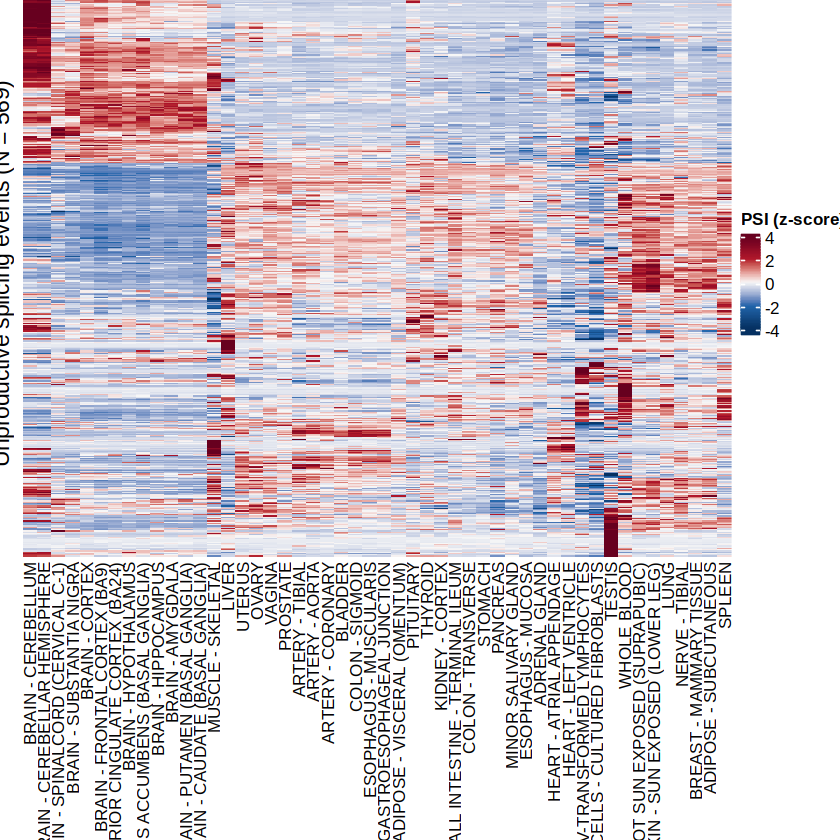

In [222]:
up_X[intron_idx, cols_orders] %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% 
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [234]:
mexp <- exp_X %>% log1p() %>% scale %>% t()%>% scale() %>% t() #[rows_orders, , drop = FALSE]
rownames(mexp) <- seq_len(nrow(mexp))

new_idx1 <- seq_along(idx1)
new_idx2 <- seq_len(length(idx2)) + max(new_idx1)
new_idx3 <- seq_len(length(idx3)) + max(new_idx2)
new_idx4 <- seq_len(length(idx4)) + max(new_idx3)
new_idx5 <- seq_len(length(idx5)) + max(new_idx4)
new_idx6 <- seq_len(length(idx6)) + max(new_idx5)

# mexp$row_id <- seq_len(nrow(mexp))


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



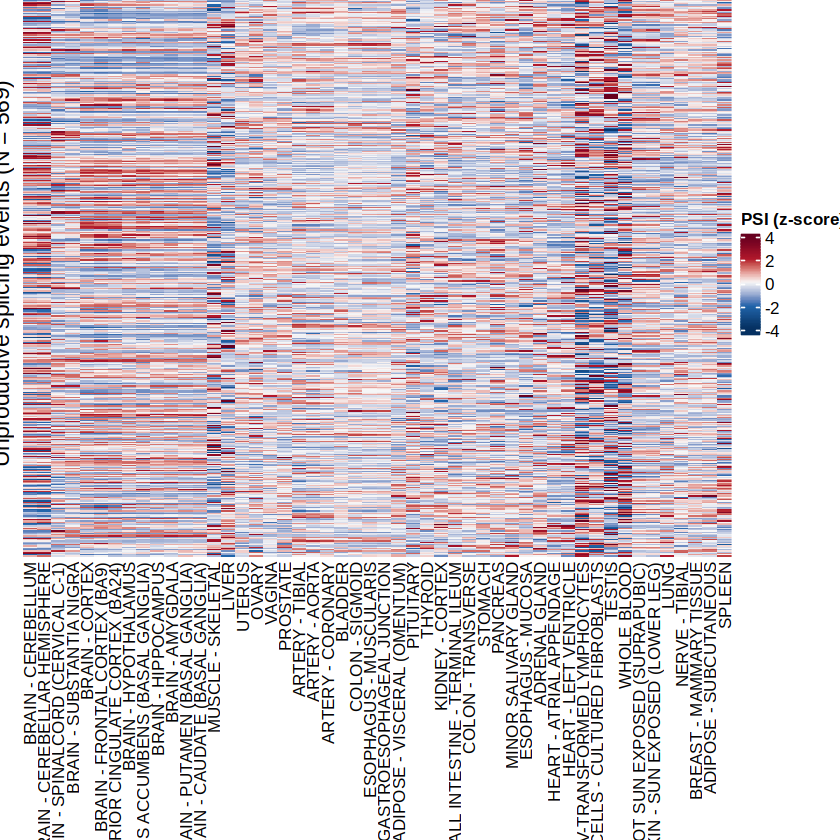

In [237]:
mexp %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



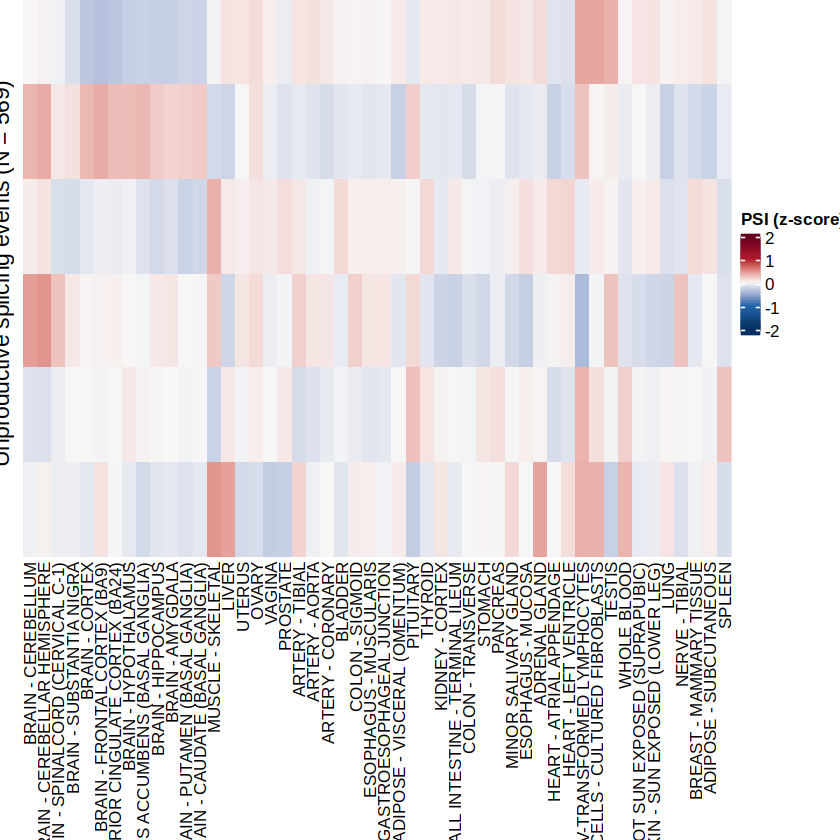

In [239]:
rbind(mexp[new_idx1,cols_orders] %>% colMeans(), 
      mexp[new_idx2,cols_orders] %>% colMeans(), 
      mexp[new_idx3,cols_orders] %>% colMeans(), 
      mexp[new_idx4,cols_orders] %>% colMeans(), 
      mexp[new_idx5,cols_orders] %>% colMeans(), 
      mexp[new_idx6,cols_orders] %>% colMeans()) %>%

Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc_exp,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [224]:
X_merge <- X %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% as.data.frame()

X_merge['intron'] <- rownames(X)


up_psi_norm <- merge(up_psi[c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id')], 
      X_merge, by = c("intron"))

ERROR: Error in `[.data.frame`(up_psi, c("intron", "cluster", "itype", "ctype", : undefined columns selected


In [42]:


up_psi_norm <- merge(up_psi[c('intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id')], 
      X_merge, by = c("intron"))

row_clusters <- row_order(ht)

# Convert list to a data frame for easy interpretation
cluster_df <- do.call(rbind, lapply(seq_along(row_clusters), function(i) {
  data.frame(intron = rownames(X)[row_clusters[[i]]], Cluster = i)
}))

colnames(cluster_df) <- c('intron', 'kcluster')
# View the first few rows
head(cluster_df)



up_psi_filter <- up_psi_norm %>% filter(intron %in% cluster_df$intron)
up_psi_filter <- merge(up_psi_filter, cluster_df, by = c("intron"))
up_psi_filter %>% write_tsv(., 'UP_clusters.tsv')

,intron,kcluster
,<chr>,<int>
1,chr21:39345274:39347378:clu_45342_-,1
2,chr21:39345958:39347246:clu_45342_-,1
3,chr21:39347478:39348291:clu_45342_-,1
4,chr21:39347483:39348291:clu_45342_-,1
5,chr22:44726634:44730609:clu_45915_+,1
6,chr22:23877171:23877384:clu_45580_+,1


In [190]:
median_expression <- read.table('/project2/mstephens/cfbuenabadn/gtex-stm/code/gtex_tables/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz',
                                sep='\t', header=TRUE, skip=2, check.names = FALSE)


In [191]:
tissues <- (up_psi_filter %>% colnames())[7:56]
up_psi_filter$gene_id <- str_remove(up_psi_filter$gene_id, "\\..*$")
median_expression$gene_id <- str_remove(median_expression$Name, "\\..*$")


ERROR: Error in `$<-.data.frame`(`*tmp*`, gene_id, value = character(0)): replacement has 0 rows, data has 868


In [45]:
colnames(median_expression) <- colnames(median_expression) %>% toupper()
colnames(up_psi_filter) <- colnames(up_psi_filter) %>% toupper()
row_order <- row_order(ht)
col_order <- column_order(ht)
idx <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
out <- median_expression[idx[!is.na(idx)], ]

In [184]:
up_X <- X
colnames(up_X) <- colnames(up_X) %>% toupper()

cols_orders <- c(colnames(X)[col_order['1'][[1]]], colnames(X)[col_order['2'][[1]]], colnames(X)[col_order['3'][[1]]]) %>% toupper()
idx1 <- match(up_psi_filter[row_order['1'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx2 <- match(up_psi_filter[row_order['2'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx3 <- match(up_psi_filter[row_order['3'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx4 <- match(up_psi_filter[row_order['4'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx5 <- match(up_psi_filter[row_order['5'][[1]],]$GENE_ID, median_expression$GENE_ID)
idx6 <- match(up_psi_filter[row_order['6'][[1]],]$GENE_ID, median_expression$GENE_ID)

rows_orders <- c(idx1, idx2, idx3, idx4, idx5, idx6)

intron_idx1 <- up_psi_filter[row_order['1'][[1]],]$INTRON
intron_idx2 <- up_psi_filter[row_order['2'][[1]],]$INTRON
intron_idx3 <- up_psi_filter[row_order['3'][[1]],]$INTRON
intron_idx4 <- up_psi_filter[row_order['4'][[1]],]$INTRON
intron_idx5 <- up_psi_filter[row_order['5'][[1]],]$INTRON
intron_idx6 <- up_psi_filter[row_order['6'][[1]],]$INTRON

intron_idx <- c(intron_idx1, intron_idx2, intron_idx3, intron_idx4, intron_idx5, intron_idx6)

median_expression['BRAIN - SPINALCORD (CERVICAL C-1)'] <- median_expression['BRAIN - SPINAL CORD (CERVICAL C-1)']

exp_X <- median_expression[rows_orders, cols_orders]

In [185]:
mexp <- median_expression[rows_orders, , drop = FALSE]
rownames(mexp) <- seq_len(nrow(mexp))

new_idx1 <- seq_along(idx1)
new_idx2 <- seq_len(length(idx2)) + max(new_idx1)
new_idx3 <- seq_len(length(idx3)) + max(new_idx2)
new_idx4 <- seq_len(length(idx4)) + max(new_idx3)
new_idx5 <- seq_len(length(idx5)) + max(new_idx4)
new_idx6 <- seq_len(length(idx6)) + max(new_idx5)

mexp$row_id <- seq_len(nrow(mexp))


In [186]:
mexp_n <- mexp[,cols_orders] %>% log1p() %>% scale %>% t()%>% scale() %>% t()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



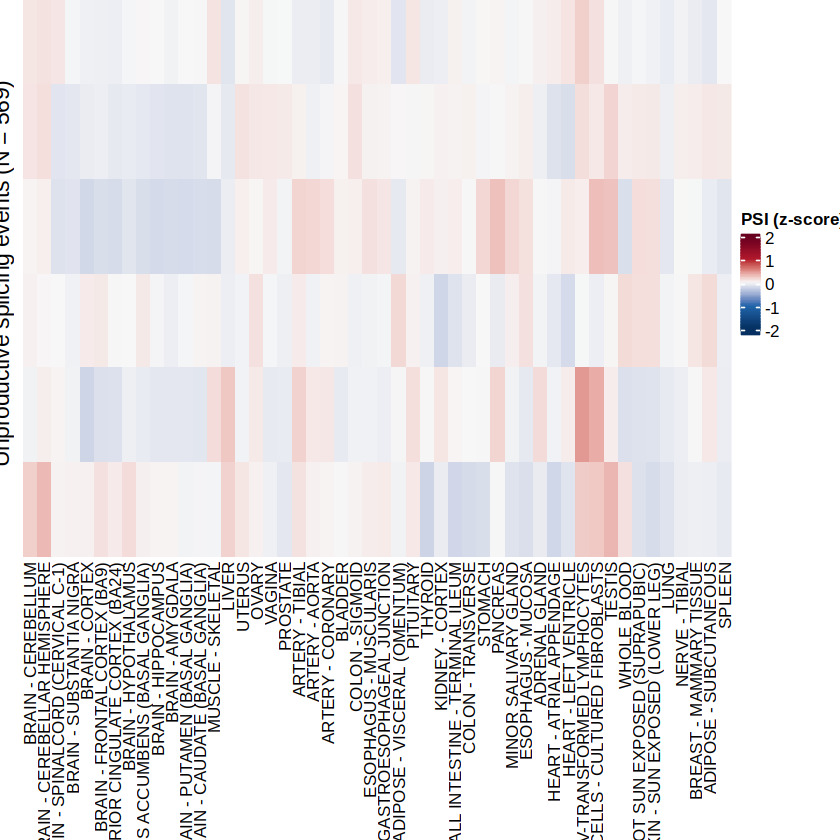

In [187]:
legendBreaks_exp <- seq(-2, 2, 1)
# colors <- rev(RColorBrewer::brewer.pal(length(legendBreaks), "RdBu"))
colors <- c("#053061", "#2166AC", "#F7F7F7", "#B2182B", "#67001F")
colfunc_exp <- circlize::colorRamp2(
  breaks = legendBreaks_exp, 
  colors = colors
  )


rbind(mexp_n[new_idx1,cols_orders] %>% colMeans(), 
      mexp_n[new_idx2,cols_orders] %>% colMeans(), 
      mexp_n[new_idx3,cols_orders] %>% colMeans(), 
      mexp_n[new_idx4,cols_orders] %>% colMeans(), 
      mexp_n[new_idx5,cols_orders] %>% colMeans(), 
      mexp_n[new_idx6,cols_orders] %>% colMeans()) %>%
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc_exp,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [188]:
up_X_n <- up_X[intron_idx, cols_orders] %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() 

rbind(up_X_n[intron_idx1,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx2,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx3,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx4,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx5,cols_orders] %>% colMeans(), 
      up_X_n[intron_idx6,cols_orders] %>% colMeans()) %>%
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

ERROR: Error in up_X_n[intron_idx1, cols_orders]: subscript out of bounds


In [189]:
up_X_n[intron_idx6,cols_orders]

ERROR: Error in up_X_n[intron_idx6, cols_orders]: subscript out of bounds


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



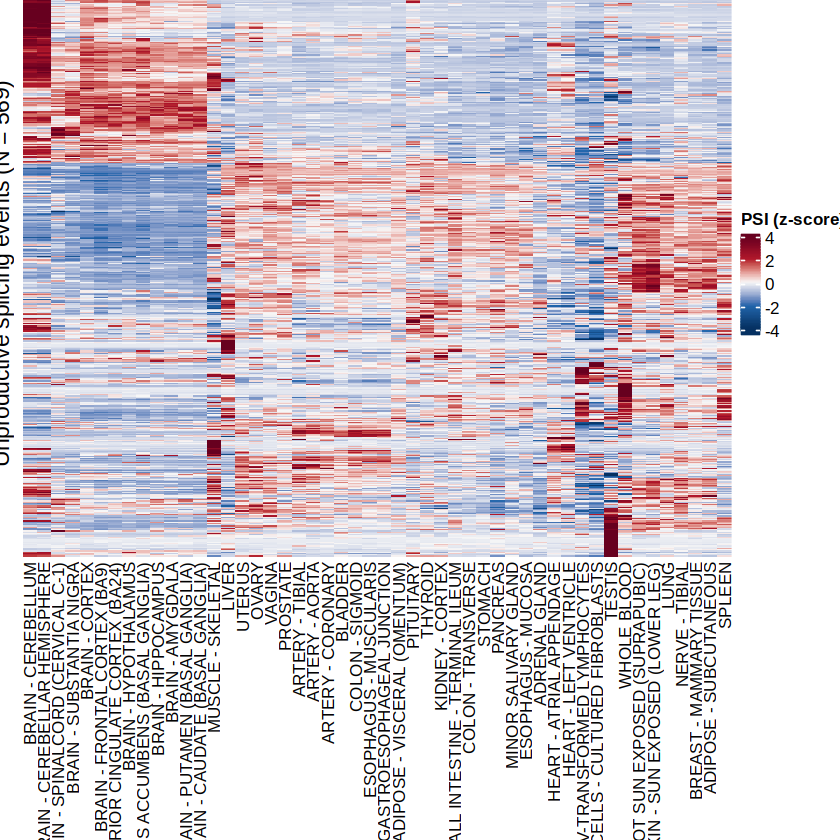

In [183]:
up_X[intron_idx, cols_orders] %>%
  as.matrix() %>% 
  t() %>% 
  scale() %>% 
  t() %>% 
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [159]:
exp_X

,BRAIN - CEREBELLUM,BRAIN - CEREBELLAR HEMISPHERE,BRAIN - SPINALCORD (CERVICAL C-1),BRAIN - SUBSTANTIA NIGRA,BRAIN - CORTEX,BRAIN - FRONTAL CORTEX (BA9),BRAIN - ANTERIOR CINGULATE CORTEX (BA24),BRAIN - HYPOTHALAMUS,BRAIN - NUCLEUS ACCUMBENS (BASAL GANGLIA),BRAIN - HIPPOCAMPUS,⋯,CELLS - CULTURED FIBROBLASTS,TESTIS,WHOLE BLOOD,SKIN - NOT SUN EXPOSED (SUPRAPUBIC),SKIN - SUN EXPOSED (LOWER LEG),LUNG,NERVE - TIBIAL,BREAST - MAMMARY TISSUE,ADIPOSE - SUBCUTANEOUS,SPLEEN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000181804,2.36784,1.790190,24.27780,9.800570,4.577170,4.733720,4.587630,7.997730,5.616320,5.611600,⋯,6.022470,1.62856,2.987180,12.293800,12.933600,11.46850,8.24604,7.82373,12.572000,14.74420
ENSG00000178665,1.79193,1.635650,3.11698,1.483750,1.284630,1.412780,1.147650,1.598760,1.323880,1.360960,⋯,0.564118,5.79110,0.115089,0.824906,0.876582,1.15025,1.85246,1.08670,0.891735,0.64040
ENSG00000151725,1.36648,1.772880,1.30113,0.533985,0.341962,0.426974,0.348168,0.401045,0.630825,0.567102,⋯,15.852100,145.39100,1.328550,12.135600,11.435100,2.80969,2.56190,2.43792,2.474900,4.58156
ENSG00000107036,11.70100,11.397200,4.90313,2.803020,4.064500,3.934930,2.944390,3.080340,3.254920,2.976660,⋯,22.399600,14.07050,4.654190,19.270800,19.350900,19.43520,21.55040,15.84140,17.997600,13.56060
ENSG00000122707,7.48650,8.572870,4.52059,3.121910,2.878860,3.408520,2.674380,2.701720,3.103630,3.212100,⋯,89.211800,8.03052,0.627930,5.735270,6.425040,21.96970,20.49150,17.97540,17.833300,5.92433
ENSG00000104375,0.95822,0.705877,4.91868,2.278700,1.668720,1.624840,1.371100,1.656130,1.410420,1.711150,⋯,8.846020,11.90470,1.813320,7.510760,7.651410,11.09770,13.02790,11.17640,12.577900,5.11302
ENSG00000183048,12.02870,11.234900,16.05970,8.640750,9.498560,9.116210,7.699800,7.070590,6.040850,4.904560,⋯,9.889970,72.57140,1.554010,24.358800,24.874900,7.45566,41.45640,22.59660,19.616300,6.68182
ENSG00000048028,32.05650,33.763400,5.45801,3.407880,7.144060,6.317720,3.912680,3.705840,3.681400,3.505210,⋯,15.135000,13.51520,2.982950,6.502120,6.979190,9.89396,10.57960,8.61111,8.135430,13.02870
ENSG00000139370,23.60610,28.856000,17.78120,9.533460,8.842850,10.764500,7.976880,10.302400,8.276980,8.418360,⋯,34.011900,34.66880,56.005500,21.363700,23.617300,26.03780,32.21600,24.75210,27.548400,28.77660


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



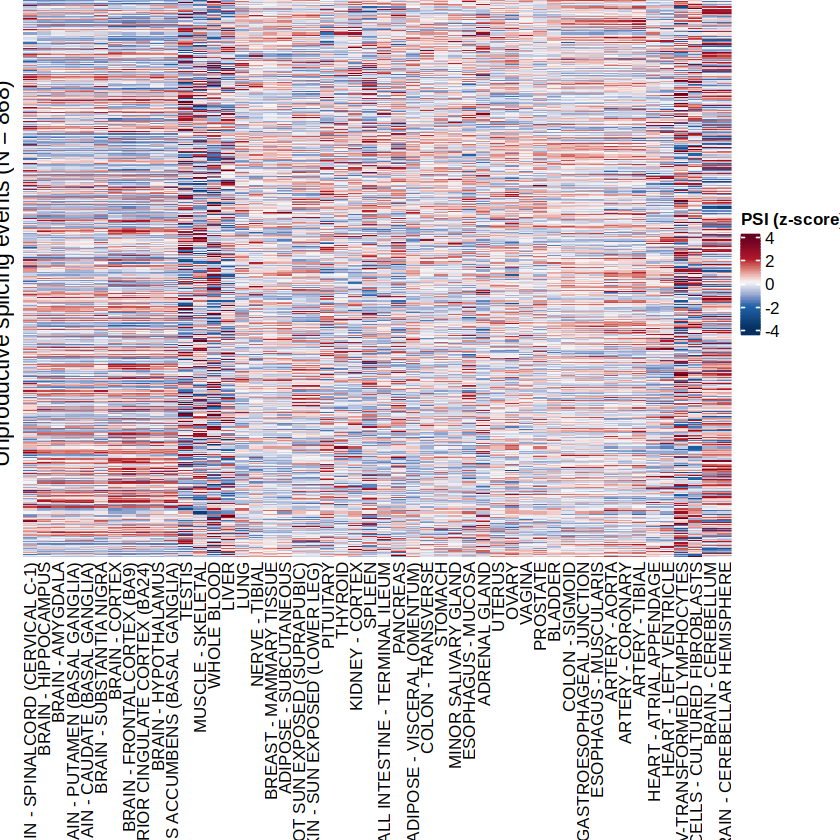

In [50]:
exp_X %>% log1p() %>% scale %>% t()%>% scale() %>% t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


In [51]:
tissues_v <- (counts %>% colnames())[7:1231]
result <- counts %>% filter(ctype == 'PR,UP') %>%
  # 1. Filter rows with at most 40% NA in tissue columns
  filter(
    rowMeans(is.na(across(all_of(tissues_v)))) <= 0.4
  ) %>%
  
  # 2. Replace remaining NA with 0 in tissue columns
  mutate(
    across(all_of(tissues_v), ~ replace_na(.x, 0))
  ) %>%
  
  # 3. Compute median across tissues
  rowwise() %>%
  mutate(
    median_tissue = mean(c_across(all_of(tissues_v)))
  ) %>%
  ungroup() %>%
  
  # 4. For each gene_id, keep the row with the highest median
  group_by(gene_id) %>%
  slice_max(median_tissue, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  
  # 5. Select requested output columns
  select(cluster, gene_name, gene_id, median_tissue)

In [106]:
tissues <- colnames(psi)[7:56]
top_psi <- psi %>% filter(cluster %in% result$cluster, ctype == 'PR,UP', itype=='UP') %>%
filter(
    rowMeans(is.na(across(all_of(tissues)))) <= 0.25
  ) %>%
  
  # 2. Replace remaining NA with 0 in tissue columns
  mutate(
    across(all_of(tissues), ~ replace_na(.x, 0))
  ) %>%
filter(
    rowMeans(across(all_of(tissues))) >= 0.25
  ) %>%
rowwise() %>%
  filter(
    max(c_across(all_of(tissues))) >= 0.5
  ) %>%

# rowwise() %>%
  mutate(
    mean_tissue = mean(c_across(all_of(tissues)))
  ) %>%
  ungroup() %>%
  
  # 4. For each gene_id, keep the row with the highest median
  group_by(gene_id) %>%
  slice_max(mean_tissue, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  
  # 5. Select requested output columns
  select(intron, cluster, gene_name, gene_id, mean_tissue)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



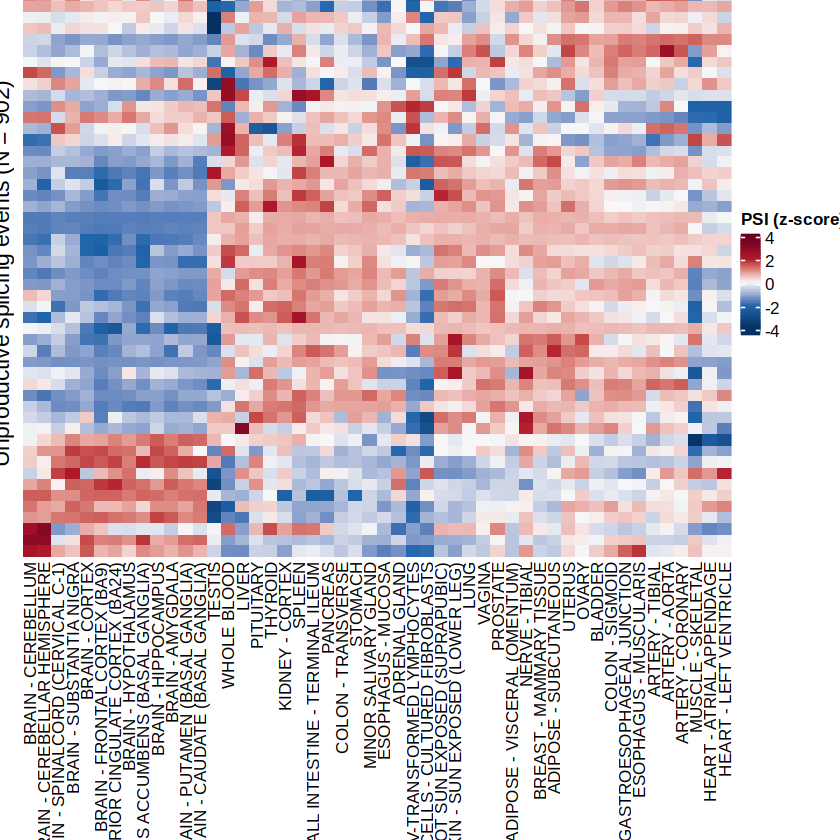

In [107]:
up_filtered_X <- up_X[intron_idx[intron_idx %in% top_psi$intron],cols_orders]
up_filtered_X %>% t()%>% scale() %>% t() %>% 
  Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



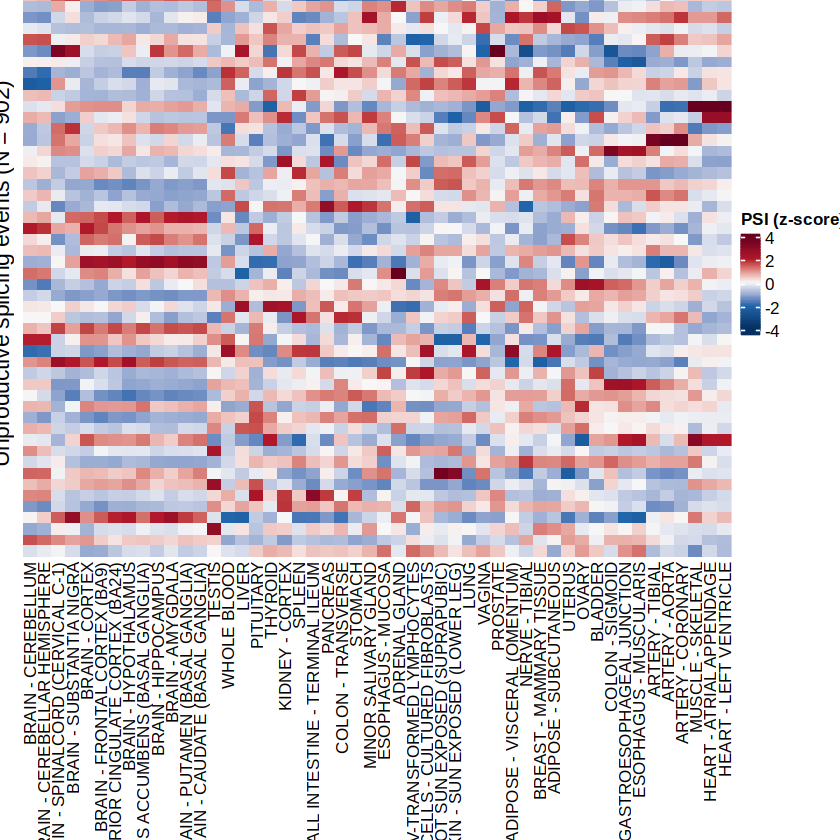

In [108]:
(median_expression[rows_orders[intron_idx %in% top_psi$intron], cols_orders] %>%log1p() %>% t() %>% scale() %>% t() %>% scale()) %>% #as.data.frame() #%>% heatmap()
Heatmap(
    row_title = glue::glue("Unproductive splicing events (N = {nrow(X)})"),
    col = colfunc,  # Example color function
    # row_km = 6, row_gap = unit(0.5, "mm"), 
    # column_km = 3, column_gap = unit(0.5, "mm"),
    show_parent_dend_line = FALSE,
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_dend = FALSE,
    heatmap_legend_param = list(title = "PSI (z-score)"),
    use_raster = TRUE, raster_quality = 2,
    # bottom_annotation = column_ha,
      width = unit(15, "cm"),  # Adjust width
    height = unit(12, "cm"), column_names_gp = gpar(fontsize = 10) 
  )

In [111]:
up_X[intron_idx[intron_idx %in% top_psi$intron],]

,ARTERY - AORTA,BRAIN - CORTEX,BRAIN - NUCLEUS ACCUMBENS (BASAL GANGLIA),ESOPHAGUS - MUSCULARIS,ADIPOSE - VISCERAL (OMENTUM),ADRENAL GLAND,ARTERY - CORONARY,BLADDER,BRAIN - AMYGDALA,BRAIN - ANTERIOR CINGULATE CORTEX (BA24),⋯,BREAST - MAMMARY TISSUE,CELLS - EBV-TRANSFORMED LYMPHOCYTES,COLON - SIGMOID,COLON - TRANSVERSE,LIVER,MUSCLE - SKELETAL,NERVE - TIBIAL,SKIN - NOT SUN EXPOSED (SUPRAPUBIC),SKIN - SUN EXPOSED (LOWER LEG),WHOLE BLOOD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr12:6905759:6906408:clu_27617_+,0.6063961,0.51898748,0.57657143,0.5462430,0.5163322,0.5032007,0.5991413,0.5285359,0.49832538,0.54773467,⋯,0.4947570,0.32626708,0.5541379,0.5219182,0.38664467,0.400340003,0.5390712,0.45858844,0.50481822,0.47224734
chr2:46958552:46974972:clu_4904_+,0.5109669,0.49973218,0.46481152,0.5465849,0.5074728,0.4057908,0.5300664,0.4573218,0.45285967,0.44971419,⋯,0.4588521,0.09702202,0.5389608,0.3281820,0.25065567,0.495293257,0.5328521,0.14044712,0.16416458,0.11231020
chr11:33702737:33710205:clu_26498_-,0.8284515,0.80796587,0.84802177,0.8229548,0.6782716,0.8072917,0.8321759,0.8279360,0.77800464,0.80481072,⋯,0.7703450,0.92000409,0.8670862,0.8463588,0.78505465,0.782381001,0.8447758,0.84442799,0.84859161,0.92618245
chr6:169634525:169638538:clu_17050_-,0.8139959,0.82997705,0.81894800,0.8357307,0.8431292,0.8371696,0.8157784,0.8113472,0.76234089,0.80543424,⋯,0.8280003,0.80677341,0.8469129,0.8434289,0.89118483,0.849025844,0.8049606,0.86988931,0.79177261,0.74363760
chr22:19970743:19971885:clu_46057_-,0.9437578,0.26624676,0.25942711,0.8782427,0.8265746,0.5149606,0.9203571,0.7836715,0.19839143,0.17524024,⋯,0.5744034,0.70973489,0.7920080,0.4715655,0.47340028,0.962268842,0.6432304,0.60141554,0.58073202,0.81126212
chr1:205662126:205662307:clu_4274_-,0.6148459,0.29097136,0.18187165,0.4455125,0.3356367,0.1552509,0.4897307,0.3672136,0.20030709,0.24348392,⋯,0.3444305,0.16991448,0.4437308,0.2810986,0.18933508,0.147525998,0.4355251,0.29313564,0.23133361,0.39475856
chr19:48119190:48120166:clu_43432_-,0.4637663,0.35423828,0.43857934,0.5118785,0.4280296,0.4101290,0.4977652,0.4836684,0.48251885,0.38930799,⋯,0.4119484,0.08981723,0.5521020,0.3956817,0.46490510,0.180901068,0.4383662,0.28358186,0.18562906,0.41517360
chr1:2558468:2558880:clu_73_+,0.4913778,0.41220836,0.26658829,0.4717294,0.3621506,0.2045988,0.4144059,0.4504191,0.20817324,0.24684288,⋯,0.4874424,0.08684865,0.5374629,0.3965900,0.23651223,0.436567198,0.4116603,0.56185366,0.62795897,0.09127577
chr8:89758233:89765340:clu_20038_+,0.3370806,0.28802823,0.35541731,0.3584231,0.2448960,0.2346979,0.2656271,0.3212021,0.31954093,0.30695235,⋯,0.3234081,0.30210405,0.3666382,0.2694651,0.17364997,0.324256357,0.3282088,0.34699463,0.31499796,0.51245840


In [116]:
psi %>% filter(intron == 'chr6:169634525:169638538:clu_17050_-')

intron,cluster,itype,ctype,gene_name,gene_id,Artery.Aorta,Brain.Cortex,Brain.Nucleusaccumbens_basalganglia,Esophagus.Muscularis,⋯,Breast.MammaryTissue,Cells.EBV.transformedlymphocytes,Colon.Sigmoid,Colon.Transverse,Liver,Muscle.Skeletal,Nerve.Tibial,Skin.NotSunExposed_Suprapubic,Skin.SunExposed_Lowerleg,WholeBlood
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr6:169634525:169638538:clu_17050_-,chr6:clu_17050_-,UP,"PR,UP",WDR27,ENSG00000184465.15,0.8139959,0.8299771,0.818948,0.8357307,⋯,0.8280003,0.8067734,0.8469129,0.8434289,0.8911848,0.8490258,0.8049606,0.8698893,0.7917726,0.7436376


In [110]:
median_expression[rows_orders[intron_idx %in% top_psi$intron], c()]

,NAME,DESCRIPTION,ADIPOSE - SUBCUTANEOUS,ADIPOSE - VISCERAL (OMENTUM),ADRENAL GLAND,ARTERY - AORTA,ARTERY - CORONARY,ARTERY - TIBIAL,BLADDER,BRAIN - AMYGDALA,⋯,SMALL INTESTINE - TERMINAL ILEUM,SPLEEN,STOMACH,TESTIS,THYROID,UTERUS,VAGINA,WHOLE BLOOD,GENE_ID,BRAIN - SPINALCORD (CERVICAL C-1)
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
32664,ENSG00000010626.14,LRRC23,6.119010,5.509850,6.628700,10.982500,9.407870,7.47606,8.47862,11.358900,⋯,4.210810,4.58726,4.502250,58.92460,12.62160,13.63920,8.07304,1.503080,ENSG00000010626,14.25960
5799,ENSG00000068724.15,TTC7A,25.965600,17.759700,31.761200,23.841300,21.928600,19.28660,13.64740,5.781470,⋯,23.812000,26.16600,10.617500,96.59770,32.86500,16.11940,22.72350,12.856500,ENSG00000068724,17.27430
30149,ENSG00000085063.14,CD59,550.188000,438.415000,214.750000,497.210000,528.025000,451.04800,308.85100,130.137000,⋯,144.716000,130.52800,232.819000,111.86900,420.96300,354.98000,366.58400,47.399600,ENSG00000085063,152.79500
19931,ENSG00000184465.15,WDR27,7.633240,6.908340,5.786170,6.930320,7.486700,6.61290,10.44640,1.939600,⋯,8.893380,10.97180,5.942860,18.93390,20.94860,17.68050,14.57620,0.656435,ENSG00000184465,2.92347
52224,ENSG00000099889.13,ARVCF,11.522600,7.285630,8.246240,56.666800,35.022200,45.77030,11.43270,12.371800,⋯,6.179770,40.06700,11.306000,19.88910,59.75990,18.74700,10.07440,1.073520,ENSG00000099889,9.60923
4190,ENSG00000158715.5,SLC45A3,2.882490,3.175760,7.401680,11.280100,6.594730,3.02644,4.63883,4.996990,⋯,9.692630,34.46740,8.881280,4.82618,3.62610,4.78511,2.99446,0.760990,ENSG00000158715,49.30600
49137,ENSG00000105486.13,LIG1,7.610810,6.097610,7.410070,7.723990,7.208450,6.83810,9.57786,4.032240,⋯,17.662800,21.26740,8.016280,29.50700,28.30980,17.47570,17.39430,5.658870,ENSG00000105486,7.56982
158,ENSG00000157873.17,TNFRSF14,96.141800,76.468000,88.178900,46.775600,65.690900,39.66930,91.44080,8.695480,⋯,158.986000,231.56400,74.558800,25.15580,106.36900,102.37300,102.31200,95.899000,ENSG00000157873,13.90350
24190,ENSG00000104312.7,RIPK2,14.518400,14.255900,4.572310,14.556400,13.767100,15.65440,11.41230,4.322750,⋯,9.015740,11.32100,7.295710,7.99272,9.75162,13.63750,11.04730,10.085800,ENSG00000104312,10.87450


In [118]:
median_expression[rows_orders[intron_idx %in% top_psi$intron], c('PROSTATE', 'VAGINA')]

,PROSTATE,VAGINA
,<dbl>,<dbl>
32664,11.00140,8.07304
5799,15.05980,22.72350
30149,243.53300,366.58400
19931,14.48120,14.57620
52224,22.21410,10.07440
4190,242.22000,2.99446
49137,16.57790,17.39430
158,147.73100,102.31200
24190,12.47280,11.04730
